In [1]:
from pathlib import Path
import os
import sys

import mne
import numpy as np

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

%matplotlib qt

Dropped 33 epochs: 4, 11, 21, 23, 27, 33, 34, 35, 37, 39, 45, 48, 49, 55, 57, 58, 60, 63, 66, 67, 69, 71, 72, 73, 75, 77, 78, 82, 85, 87, 92, 93, 96
The following epochs were marked as bad and are dropped:
[np.int64(4), np.int64(11), np.int64(21), np.int64(23), np.int64(27), np.int64(33), np.int64(34), np.int64(35), np.int64(37), np.int64(39), np.int64(45), np.int64(48), np.int64(49), np.int64(55), np.int64(57), np.int64(58), np.int64(60), np.int64(63), np.int64(66), np.int64(67), np.int64(69), np.int64(71), np.int64(72), np.int64(73), np.int64(75), np.int64(77), np.int64(78), np.int64(82), np.int64(87), np.int64(89), np.int64(95), np.int64(96), np.int64(99)]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [2]:
from utils.decode_trigger import decode_8bit_trigger, convert_dict_trigger
from utils.validation_data import filter_stationary_epochs
from modules.events import get_events_tms_per_task
from modules.ica import ICAProcessor

c:\Repositorios\msc-eeg-tms-pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
raw_data = mne.io.read_raw_bdf(r"data/raw/V2.bdf", preload=True)

Extracting BDF parameters from data/raw/V2.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 46869999  =      0.000 ...  2343.500 secs...


In [4]:
emg_ch_names = ["EMG"]
eog_ch_names = ["EOG"]
raw_data.set_channel_types({ch: "emg" for ch in emg_ch_names})
raw_data.set_channel_types({'EOG':'eog'})

montage = mne.channels.make_standard_montage("standard_1020",head_size='auto')
raw_data.set_montage(montage)

<RawBDF | V2.bdf, 34 x 46870000 (2343.5 s), ~11.87 GiB, data loaded>

In [5]:
raw_data.drop_channels(emg_ch_names)

<RawBDF | V2.bdf, 33 x 46870000 (2343.5 s), ~11.52 GiB, data loaded>

Using matplotlib as 2D backend.


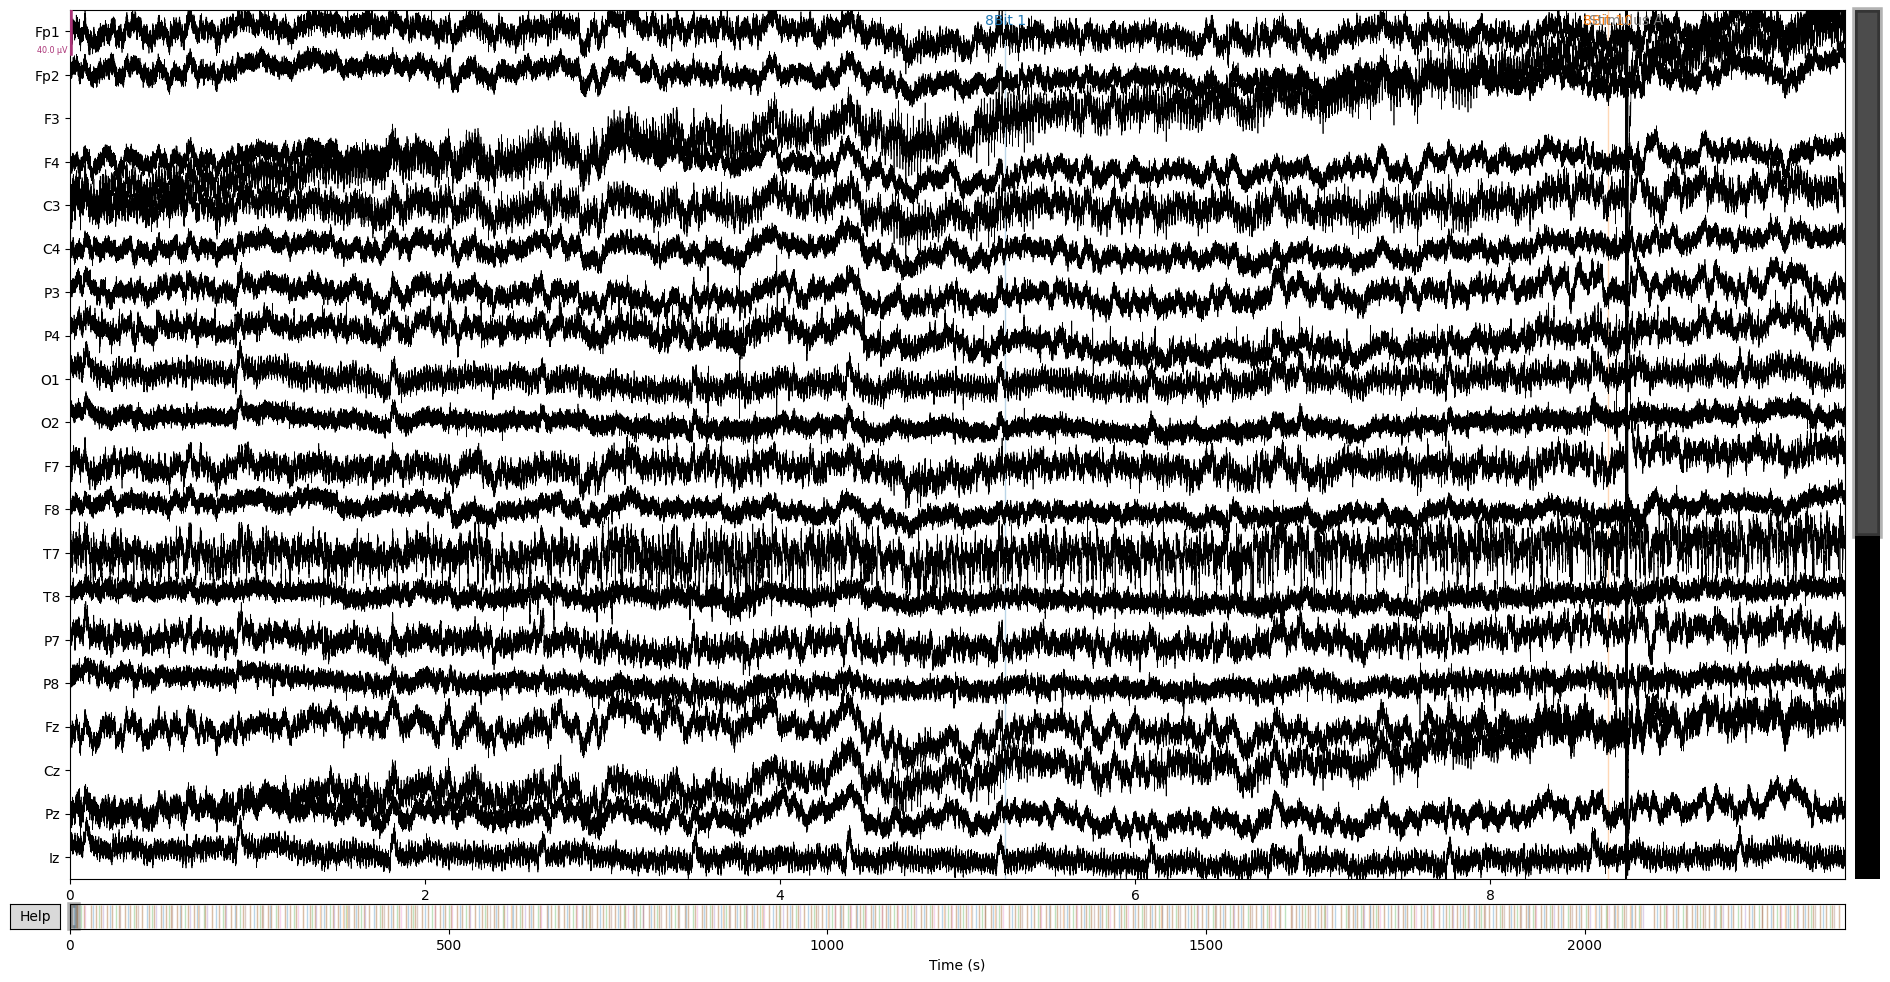

In [8]:
raw_data.plot()

In [7]:
bad_ch =['F7', 'F5', 'P7', 'CPz', 'Oz', 'Iz', 'PO4', 'PO8', 'O2', "P6", "P8", "TP8", "C6", "TP10", "TP9", "F6", "FT8", "T8", "T7", "F3", "FC5", "FC3", "C3", "C1"]
raw_data.drop_channels(bad_ch)

<RawBDF | V1.bdf, 41 x 12595000 (2519.0 s), ~3.85 GiB, data loaded>

In [6]:
events, event_id = mne.events_from_annotations(raw_data)
event_id = raw_data.event_id = convert_dict_trigger(event_id, decode_8bit_trigger)

Used Annotations descriptions: [np.str_('8Bit 1'), np.str_('8Bit 10'), np.str_('8Bit 2'), np.str_('8Bit 3'), np.str_('8Bit 4'), np.str_('8Bit 5'), np.str_('Stimulus A')]


In [7]:
raw_data = mne.preprocessing.fix_stim_artifact(
    raw_data, 
    events=events,
    event_id=7,
    tmin=-0.004,  # -2 ms
    tmax=0.018, # 10 ms
    mode='linear'
)

In [8]:
raw_data.resample(1000)

<RawBDF | V2.bdf, 33 x 2343500 (2343.5 s), ~590.1 MiB, data loaded>

In [21]:
filtered_data = raw_data.notch_filter(freqs=[60, 120], method='spectrum_fit', filter_length='auto')

Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     60.00 : 13543 windows
    120.00 : 13543 windows


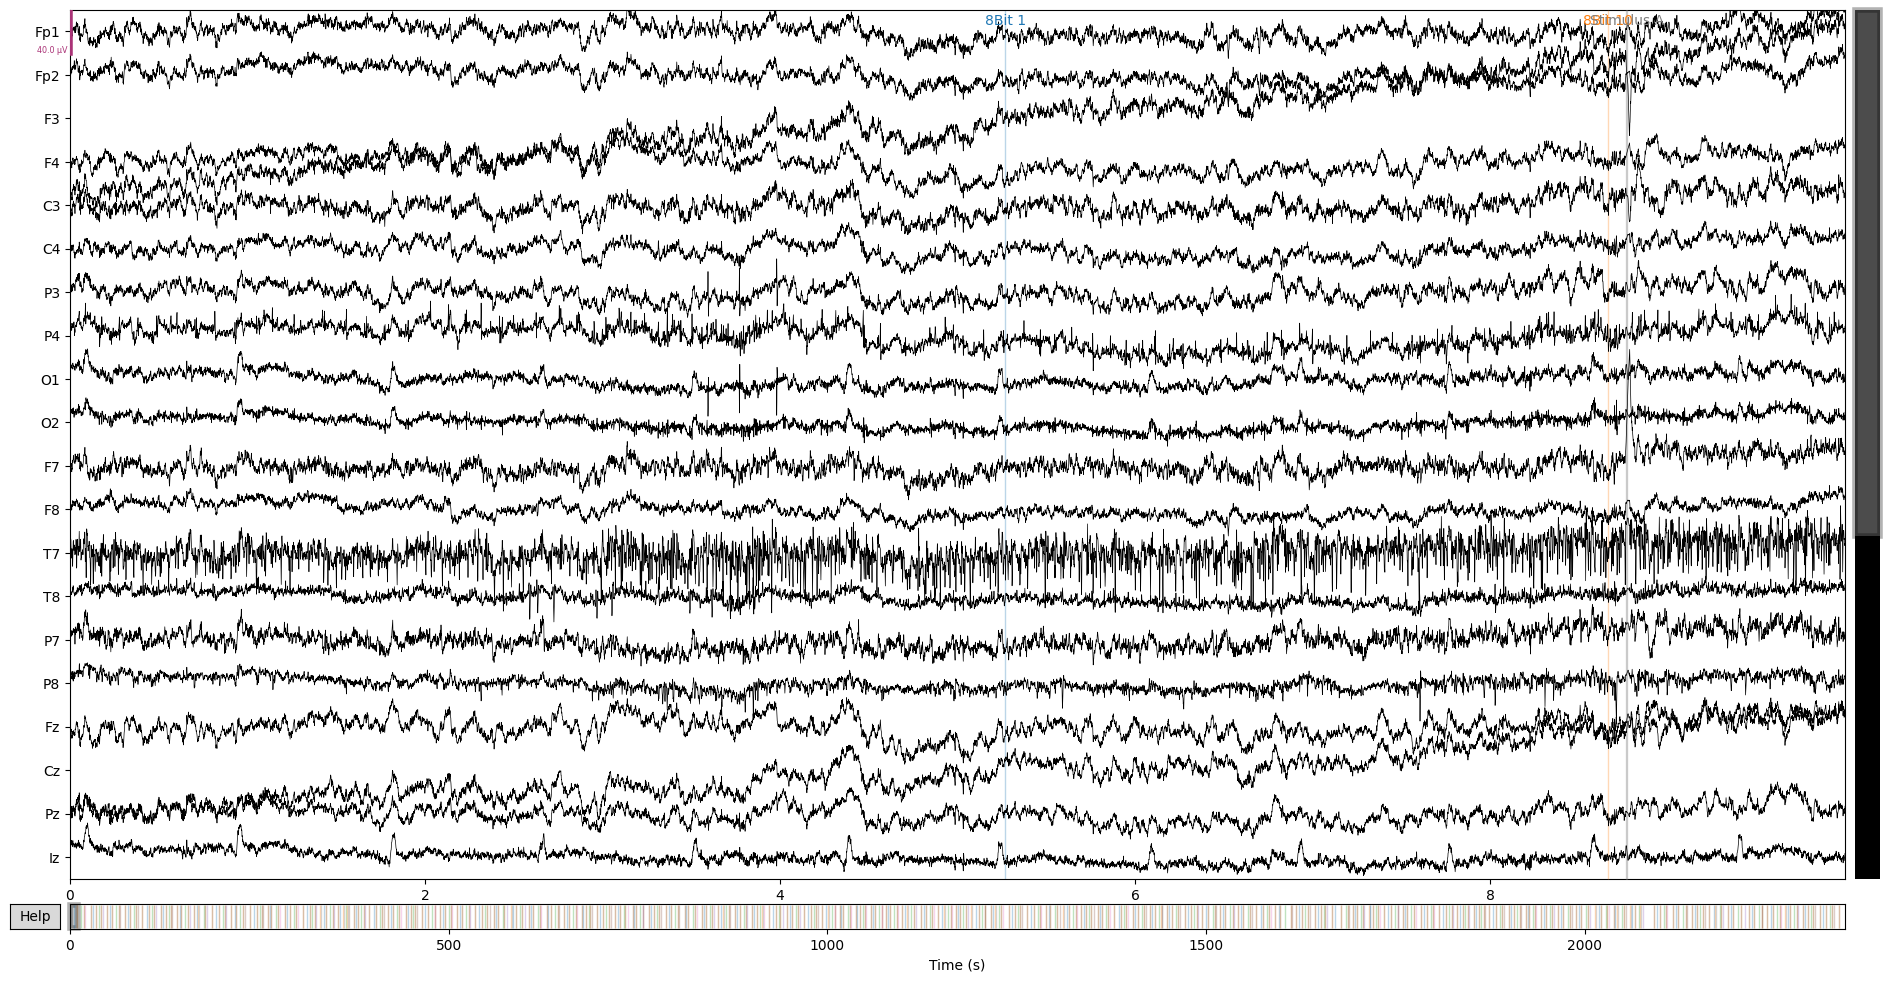

In [78]:
filtered_data.plot()

In [22]:
filtered_data.drop_channels(["TP9", "TP10", "T7", "EOG"])

ValueError: Channel(s) TP9, TP10, T7, EOG not found, nothing dropped.

In [24]:
filtered_data.filter(l_freq=1, h_freq=100, method='fir', fir_design='firwin')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 3301 samples (3.301 s)



<RawBDF | V2.bdf, 29 x 2343500 (2343.5 s), ~518.5 MiB, data loaded>

In [25]:
events, event_id = mne.events_from_annotations(raw_data)
event_id = raw_data.event_id = convert_dict_trigger(event_id, decode_8bit_trigger)

Used Annotations descriptions: [np.str_('8Bit 1'), np.str_('8Bit 10'), np.str_('8Bit 2'), np.str_('8Bit 3'), np.str_('8Bit 4'), np.str_('8Bit 5'), np.str_('Stimulus A')]


In [26]:
events_tms, events_id_tms = get_events_tms_per_task(events, event_id)

In [58]:
epochs = mne.Epochs(
    filtered_data,
    events=events_tms,
    event_id=events_id_tms,
    tmin=-4,
    tmax=-0.05,
    preload=True,
    baseline=None,
    reject_by_annotation=False
)

Not setting metadata
100 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 100 events and 3951 original time points ...
0 bad epochs dropped


In [59]:
epochs.set_eeg_reference('average', projection=False)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<Epochs | 100 events (all good), -4 – -0.05 s (baseline off), ~87.5 MiB, data loaded,
 'tms_pulse_task_right': 31
 'tms_pulse_task_left': 38
 'tms_pulse_task_bilateral': 31>

In [60]:
from autoreject import get_rejection_threshold
reject_thresholds = get_rejection_threshold(
    epochs, 
    ch_types='eeg', 
    decim=2, 
    random_state=42
)

print(f"Limiares ideais calculados: {reject_thresholds}")

Estimating rejection dictionary for eeg
Limiares ideais calculados: {'eeg': np.float64(0.0002240134813248339)}


In [61]:
epochs.drop_bad(reject=reject_thresholds)

    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'F7', 'F8', 'T8', 'FC1', 'FC2', 'FC5', 'FC6']
    Rejecting  epoch based on EEG : ['Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
3 bad epochs dropped


<Epochs | 97 events (all good), -4 – -0.05 s (baseline off), ~84.8 MiB, data loaded,
 'tms_pulse_task_right': 29
 'tms_pulse_task_left': 38
 'tms_pulse_task_bilateral': 30>

Using matplotlib as 2D backend.


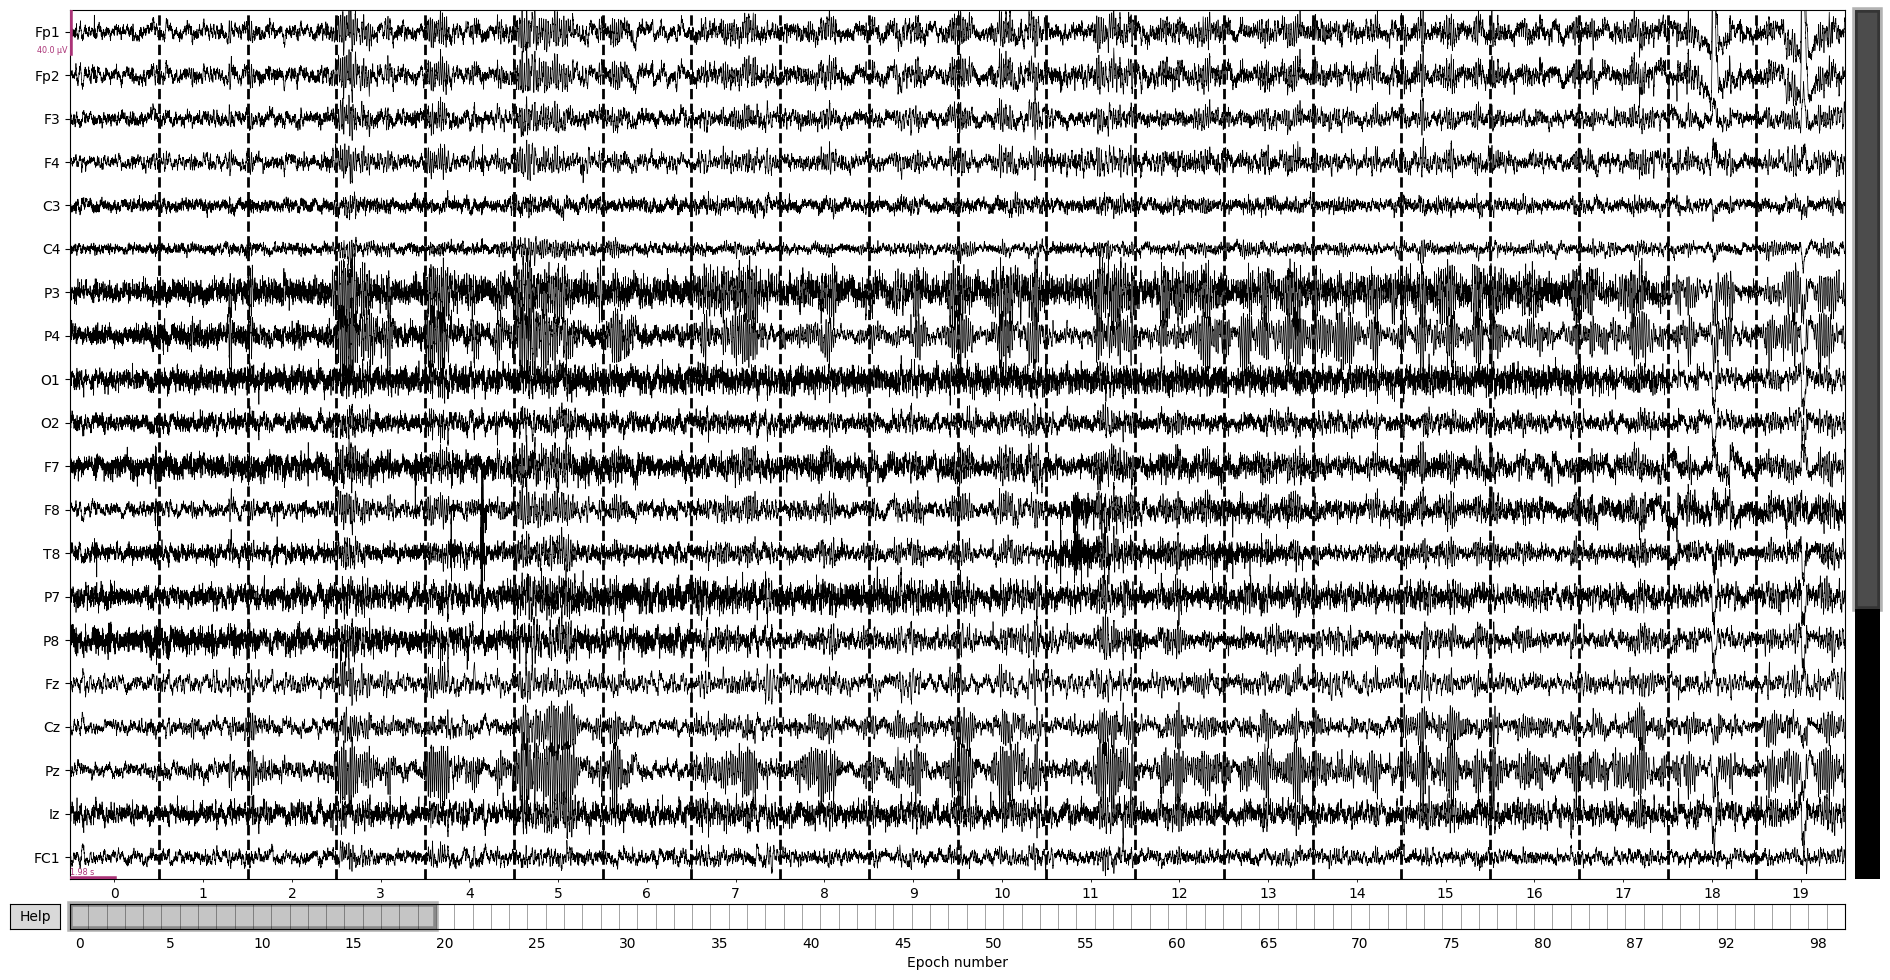

In [37]:
epochs.plot()

In [62]:
ica = ICAProcessor()

In [63]:
ica.fit(epochs)

Fitting ICA to data using 29 channels (please be patient, this may take a while)
Selecting by explained variance: 17 components
Fitting ICA took 13.6s.


In [40]:
ica.plot_components()

Not setting metadata
64 matching events found
No baseline correction applied
0 projection items activated


In [64]:
exclide_comp = ica.get_exclude_components(threshold=0.75)
exclide_comp

c:\Repositorios\msc-eeg-tms-pipeline\modules\ica.py:34: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.preprocessing.ICA' instance with the arguments 'ICA(method='infomax', fit_params=dict(extended=True))' (scikit-learn) or 'ICA(method='picard', fit_params=dict(ortho=False, extended=True))' (python-picard).
  return label_components(self.epoch, self.ica, method=method)


Avaliable componentes found: ['eye blink', 'brain', 'brain', 'brain', 'brain', 'eye blink', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'other', 'brain', 'brain', 'muscle artifact']
-> Componente 0 excluída: eye blink (Probabilidade: 0.99)
-> Componente 5 excluída: eye blink (Probabilidade: 1.00)
Applying ICA to Evoked instance
    Transforming to ICA space (17 components)
    Zeroing out 2 ICA components
    Projecting back using 29 PCA components


[0, 5]

In [65]:
epochs_clean = ica.apply_ica(exclude=exclide_comp)

Applying ICA to Epochs instance
    Transforming to ICA space (17 components)
    Zeroing out 2 ICA components
    Projecting back using 29 PCA components


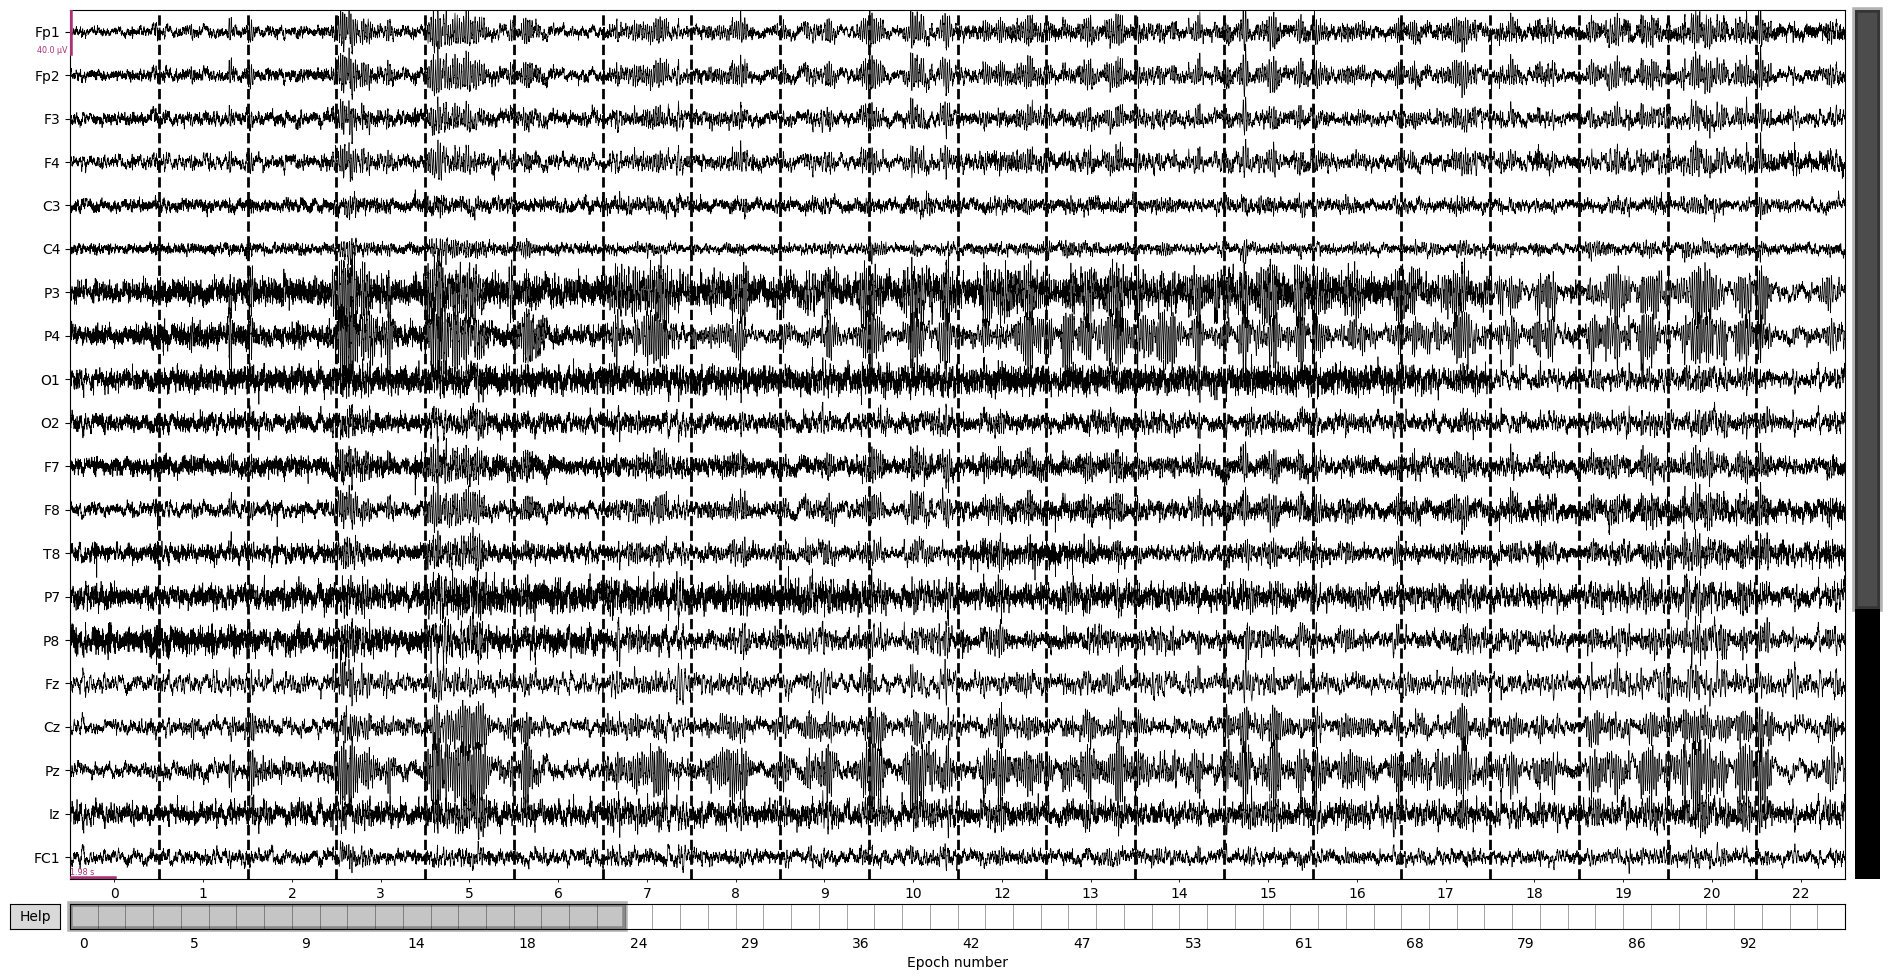

In [44]:
epochs_clean.plot()

In [66]:
epochs_clean.filter(l_freq=1, h_freq=75, method='fir')

Setting up band-pass filter from 1 - 75 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 75.00 Hz
- Upper transition bandwidth: 18.75 Hz (-6 dB cutoff frequency: 84.38 Hz)
- Filter length: 3301 samples (3.301 s)



<Epochs | 97 events (all good), -4 – -0.05 s (baseline off), ~84.8 MiB, data loaded,
 'tms_pulse_task_right': 29
 'tms_pulse_task_left': 38
 'tms_pulse_task_bilateral': 30>

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


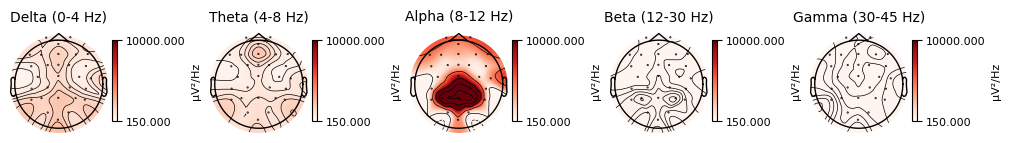

In [67]:
epochs_clean['tms_pulse_task_bilateral'].compute_psd().plot_topomap(vlim=(150, 10000))
epochs_clean['tms_pulse_task_left'].compute_psd().plot_topomap(vlim=(150, 10000))
epochs_clean['tms_pulse_task_right'].compute_psd().plot_topomap(vlim=(150, 10000))

In [68]:
epochs_clean.crop(-2, -0.05)

<Epochs | 97 events (all good), -2 – -0.05 s (baseline off), ~41.9 MiB, data loaded,
 'tms_pulse_task_right': 29
 'tms_pulse_task_left': 38
 'tms_pulse_task_bilateral': 30>

In [70]:
epochs_clean_validated = filter_stationary_epochs(epochs_clean)

Testing stationarity (ADF Test)... This might take a few seconds depending on data size.

--- Summary ---
Total epochs evaluated: 97
Stationary epochs KEPT: 97
Non-stationary epochs DROPPED: 0


In [ ]:
epochs_clean_validated.save("data/processed/V2/epochs-mvar.fif", overwrite=True)

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


C:\Users\marci\AppData\Local\Temp\ipykernel_23028\3689829046.py:1: RuntimeWarning: This filename (data/processed/V2/epochs-mvar.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_clean.save("data/processed/V2/epochs-mvar.fif", overwrite=True)


[WindowsPath('c:/Repositorios/msc-eeg-tms-pipeline/data/processed/V2/epochs-mvar.fif')]